In [56]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [57]:
# this could use some cleaning up

# MODEL PARAMETERS
grid_size_r, grid_size_z, grid_size_theta = 32, 32, 32 # eulerian grid size, 32 x 32 x 32
sim_prop = 1e-9 # percentage of particles to simulate
t_final = 1000 # total number of time steps

# PHYSICAL CONSTANTS
kB = 1.3806503e-23 # boltzmann constant
q = 1.60217733e-19 # fundamental charge
eps0 = 8.85418782e-12 # epsilon0
mu0 = 1.256637061e-6 # mu0

mp, me = 2*1.672621925e-27, 9.1093837139e-31

c = 1 / jnp.sqrt(mu0 * eps0)

# GEOMETRY AND STUFF
r_min, r_max = 0.8, 1.2
z_min, z_max = -0.2, 0.2

#Temperature, Magnetic, Num Particles, R0
R0 = (r_max - r_min) # length of the cylinder disk
clustering = 25.0 # how localized the normal distirbution is.

N0 = 1e14 # number of particles in plasma
ionization = .5 # percentage of protons to electrons

B0 = 1 # background B field
T0 = 4000 # initial characteristic temperature

# DERIVED VALUES
N_e0 = (1 - ionization) * N0 # number of electrons
N_p0 = ionization * N0 # number of protons
N_e = int(N_e0 * sim_prop) # number of electrons to simulate
N_p = int(N_p0 * sim_prop) # number of protons to simulate

v0 = jnp.sqrt(kB*T0/me) # characteristic velocity for an electron. proton is going to be off, but whatever

# Charecteristic scales
t0 = me / (q * B0) # characteristic timescale
E0 = v0 * B0 # characteristic E field'
L0 = v0 * t0 # characteristic length scale, will be used to update positions but not for the grid itself
V0 = E0 * R0 # characteristic electric potential

dt0 = 0.1 #time step is a tenth of characteristic time scale

V_dom = jnp.pi * (r_max**2 - r_min**2) * (z_max - z_min)

n0 = N0 / V_dom  # reference number density
rho0 = q * n0    # characteristic charge density

#
plasma_freq_p = jnp.sqrt(q**2 * n0 / (eps0 * mp))
plasma_freq_e = jnp.sqrt(q**2 * n0 / (eps0 * me))

# Omega = q * B / m, cyclotron frequency
gyro_freq_p = q * B0 / mp
gyro_freq_e = -q * B0 / me

print("Proton plasma frequency: ", plasma_freq_p)
print("Electron plasma frequency: ", plasma_freq_e)
print("Proton gyrofrequency: ", gyro_freq_p)
print("Electron gyrofrequency: ", gyro_freq_e)
print("Time scale: ", t0)
print("velocity scale: ", v0)
print("length scale:n ", L0)

seed = 42
key = jax.random.PRNGKey(seed)

Proton plasma frequency:  9284796.0
Electron plasma frequency:  562654460.0
Proton gyrofrequency:  47894186.547865555
Electron gyrofrequency:  -175882077242.52948
Time scale:  5.6856276414171955e-12
velocity scale:  246222.27
length scale:n  1.3999281e-06


\begin{equation*}
\frac{d\tilde{v}}{dt} = \frac{qE_0 t_0}{mv_0} \tilde{E} + \frac{qB_0 t_0}{m} (\tilde{v} \times \tilde{B}) = \frac{\lambda_D}{R_0} \tilde{E} + \frac{\Omega_c}{\omega_p} (\tilde{v} \times \tilde{B})
\end{equation*}
I will be nondimensionalizing with coefficients $\alpha_i = \frac{q_i E_0 t_0}{m_i v_0}$ and $\beta_i = \frac{q_i B_0 t_0}{m_i}$ personally to easily separate protons from electrons, but someone else can swap these out later pretty trivially

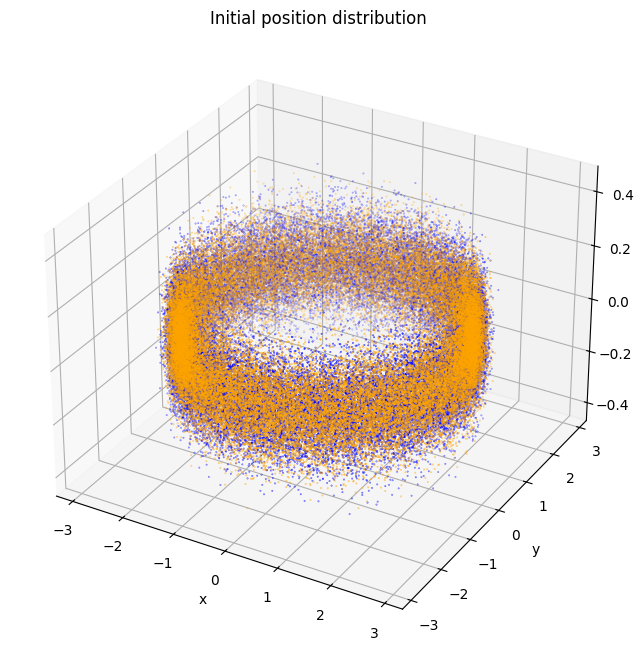

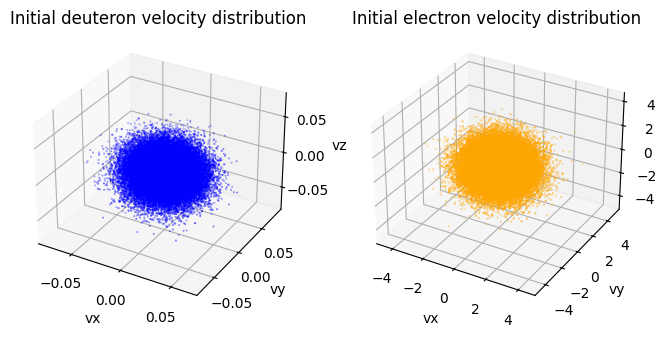

In [58]:
x_p, x_e = jnp.empty(shape=(t_final,N_p,3)), jnp.empty(shape=(t_final,N_e,3)) #Store the 3 coordinates of each particle at each time step

v_p, v_e = jnp.empty_like(x_p), jnp.empty_like(x_e) #store the 3 velocity coordinates of each particle (N) at each time step (t_final)

#Number of particles max
N = max(N_p, N_e)

#Position sampling, in meters
while True:
    # random keys for r and z
    key, key_r, key_z = jax.random.split(key, 3)

    #Sample r, z
    roffset = (r_min + r_max)/2 #if we wanted to do it right, we would only measure change in r from this point, less roundoff error, but we'll see about time
    r = (jax.random.normal(key=key_r, shape=(N,2)) / clustering + (r_min + r_max) / 2)
    z = (jax.random.normal(key=key_z, shape=(N,2)) / clustering)

    #ensure that r is inside the bounds we determined
    r_valid = jnp.all((r >= r_min) & (r <= r_max))
    z_valid = jnp.all((z >= z_min) & (z <= z_max))

    if r_valid and z_valid:
        break

r = r / L0  # convert to L0-units once, after sampling
z = z / L0


#theta sampling
key, key_theta = jax.random.split(key, 2)
theta = jax.random.uniform(key=key_theta, shape=(N, 2)) * 2 * jnp.pi

#Set r, theta, z coordinates for proton
x_p = x_p.at[0,:,0].set(r[:N_p, 0])
x_p = x_p.at[0,:,1].set(theta[:N_p, 0])
x_p = x_p.at[0,:,2].set(z[:N_p, 0])

#set r, theta, z coordinates for electron
x_e = x_e.at[0,:,0].set(r[:N_e, 1])
x_e = x_e.at[0,:,1].set(theta[:N_e, 1])
x_e = x_e.at[0,:,2].set(z[:N_e, 1])


key, key_vr, key_vz, key_vtheta = jax.random.split(key, 4)

#std deviations for Gaussian velocity sampling
sigma = jnp.array([jnp.sqrt(kB*T0/mp), jnp.sqrt(kB*T0/me)]) / v0 #dividing by v0 non-dimensionalizes

vr = jax.random.normal(key=key_vr, shape=(N, 2)) * sigma
vz = jax.random.normal(key=key_vz, shape=(N, 2)) * sigma
vtheta = jax.random.normal(key=key_vtheta, shape=(N, 2)) * sigma #note that this is v_theta, not dtheta/dt

#Setting the velocities of all the particles
v_p = v_p.at[0,:,0].set(vr[:N_p, 0])
v_p = v_p.at[0,:,1].set(vtheta[:N_p, 0])
v_p = v_p.at[0,:,2].set(vz[:N_p, 0])

v_e = v_e.at[0,:,0].set(vr[:N_e, 1])
v_e = v_e.at[0,:,1].set(vtheta[:N_e, 1])
v_e = v_e.at[0,:,2].set(vz[:N_e, 1])

# VISUALIZATION
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

x = r * jnp.cos(theta) * L0/R0
y = r * jnp.sin(theta) * L0/R0 #to make it a manageable scale for viewing, *L0/R0


#Position plot
ax.scatter(x[:N_p, 0], y[:N_p, 0], z[:N_p, 0] * L0/R0, s=0.1, color='blue')
ax.scatter(x[:N_e, 1], y[:N_e, 1], z[:N_e, 1] * L0/R0, s=0.1, color='orange')
ax.set_title("Initial position distribution")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 2, 1, projection='3d')

# velocity conversion
vx = vr * jnp.cos(theta) - vtheta * jnp.sin(theta)
vy = vr * jnp.sin(theta) + vtheta * jnp.cos(theta)

#deuteron plot
ax.scatter(vx[:N_p, 0], vy[:N_p, 0], vz[:N_p, 0], s=0.1, color='blue')
ax.set_title("Initial deuteron velocity distribution")
ax.set_xlabel("vx")
ax.set_ylabel("vy")
ax.set_zlabel("vz")

#electron plot
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.scatter(vx[:N_e, 1], vy[:N_e, 1], vz[:N_e, 1], s=0.1, color='orange')
ax.set_title("Initial electron velocity distribution")
ax.set_xlabel("vx")
ax.set_ylabel("vy")
ax.set_zlabel("vz")
plt.show()

In [59]:
#Dimensionalization factors
alpha = jnp.array([q/mp, -q/me]) * E0 * t0 / v0 #alpha and beta are the same thing
beta = jnp.array([q/mp, -q/me]) * B0 * t0

# each discretized coordinate is stored in the 1D vectors, cell edges. These are bins
r_1D = jnp.linspace(r_min / R0, r_max / R0, grid_size_r + 1) #in units of R0
theta_1D = jnp.linspace(0, 2*jnp.pi, grid_size_theta + 1) # in radians
z_1D = jnp.linspace(z_min / R0, z_max / R0, grid_size_z + 1) #also in units of R0

#get dr,dtheta, dz
dr = r_1D[1] - r_1D[0]
dtheta = theta_1D[1] - theta_1D[0]
dz = z_1D[1] - z_1D[0]

#useful for cell centers, also bins
r_grid = r_1D[0:-1] + dr / 2
theta_grid = theta_1D[0:-1] + dtheta / 2
z_grid = z_1D[0:-1] + dz / 2

# note the r**2, this is calculating the area of one specific volume block
volumes = 0.5 * jnp.diff(r_1D**2)[:, None, None] * jnp.diff(theta_1D)[None, :, None] * jnp.diff(z_1D)[None, None, :] #Volume, measured in R0**3


def compute_density(x: jnp.ndarray,
    qty=1, r_min=r_1D[0], r_max=r_1D[-1], z_min=z_1D[0], z_max=z_1D[-1], theta_min=0, theta_max=2*jnp.pi, volumes=volumes):
    #inputs
    #if qty is a velocity, this can give you current density. Else, just charge density. Give the R min, Rmax, theta min, thetamax
    #and x (positions of all particles) as values

    #math to find which idx the particle lives in in terms of r, theta, and z, which gives you the cell
    r_idx = jnp.floor((x[:, 0]*L0/R0 - r_min) / dr).astype(jnp.int32) #multiply by L0 to convert to meters
    theta_idx = jnp.floor((x[:, 1] - theta_min) / dtheta).astype(jnp.int32)
    z_idx = jnp.floor((x[:, 2]*L0/R0 - z_min) / dz).astype(jnp.int32) #multiply by L0 to convert to meters

    # safety for out of bound idx (physical interp = hits reactor wall and stays there)
    r_idx = jnp.clip(r_idx, 0, grid_size_r - 1)
    theta_idx = jnp.clip(theta_idx, 0, grid_size_theta - 1)
    z_idx = jnp.clip(z_idx, 0, grid_size_z - 1)

    #flatten idx
    flat_idx = r_idx * (grid_size_theta * grid_size_z) + theta_idx * grid_size_z + z_idx
    total_cells = grid_size_r * grid_size_theta * grid_size_z

    weights = jnp.broadcast_to(qty/sim_prop, (x.shape[0],)).ravel() #division by sim_prop important here
    cell_sums = jnp.bincount(flat_idx, weights=weights, length=total_cells)
    cell_sums = cell_sums.reshape(grid_size_r, grid_size_theta, grid_size_z)
    # return a 32x32x32 array representing density across the field
    return jnp.where(volumes > 0, cell_sums / volumes, 0.0)/(R0**3) # UNITS -> N / R0**3, so we convert to regular meters

\begin{equation*}
R_0^2 \nabla^2 \tilde{V} = - \sum_i \left(\frac{\omega_{p,i}}{\Omega_{c,i}}\right)^2 \tilde{\rho}_i
\end{equation*}

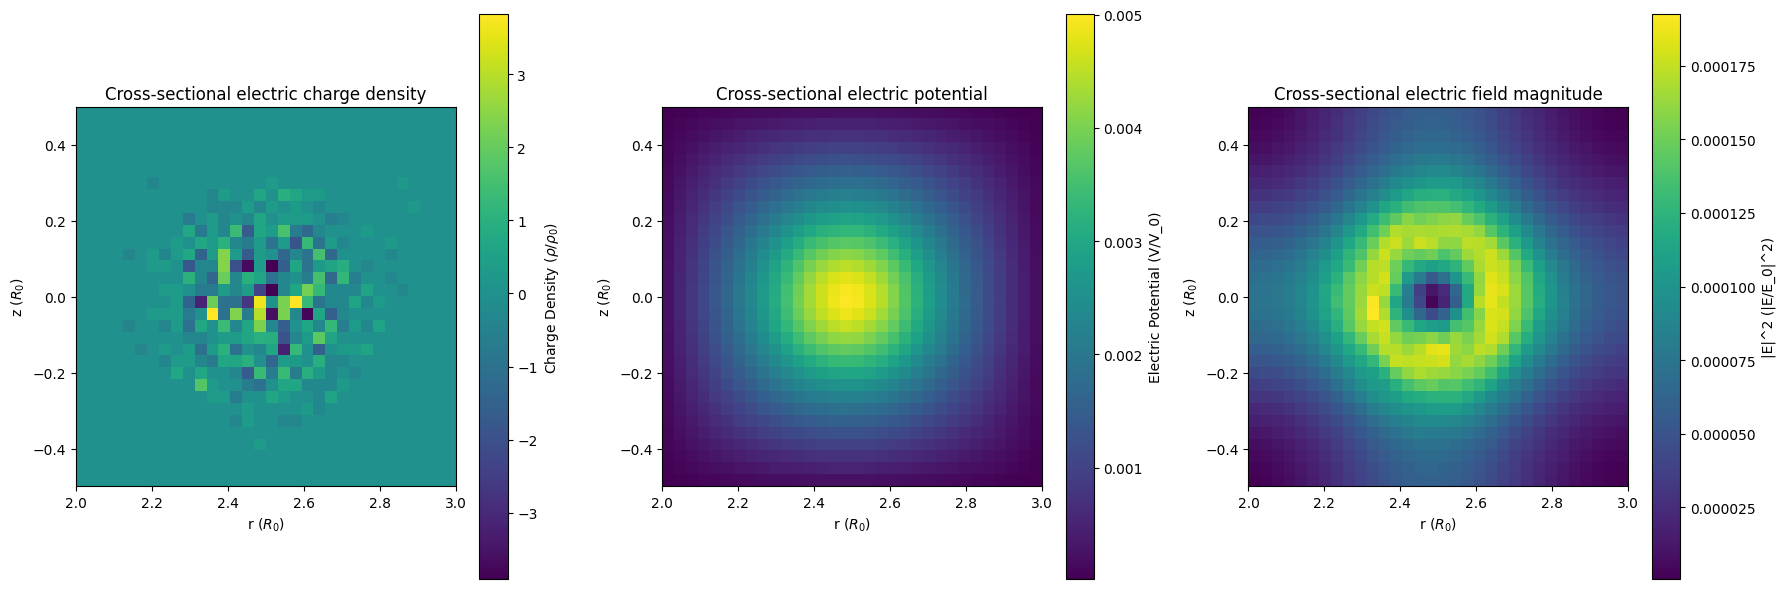

In [60]:
# https://en.wikipedia.org/wiki/Conjugate_gradient_method
# good for solving this kind of linear system

def conjugate_gradient(A, b, x0, tol=1e-8, max_iter=1000):

    def cond_fn(carry):
        _, _, _, last_res, k = carry
        return (last_res > tol) & (k < max_iter)

    def body_fn(carry):
        x, r, p, last_res, k = carry

        Ap = A(p)
        pAp = jnp.vdot(p, Ap)

        alpha = jnp.where(pAp == 0.0, 0.0, last_res / pAp)
        x = x + alpha * p
        r = r - alpha * Ap
        res = jnp.vdot(r, r)

        beta = jnp.where(last_res == 0.0, 0.0, res / last_res)
        p = r + beta * p

        return (x, r, p, res, k + 1)

    r0 = b - A(x0)
    p0 = jnp.copy(r0)
    last_res0 = jnp.vdot(r0, r0)

    x_final, _, _, _, _ = jax.lax.while_loop(cond_fn, body_fn, (x0, r0, p0, last_res0, 0))

    return x_final

def laplacian(phi: jnp.ndarray):
    # finite difference slop
    phi_padded = jnp.pad(phi, ((1, 1), (0, 0), (1, 1)), constant_values=0.0)
    r_int = r_1D[0:-1] + dr/2

    phi_rp = phi_padded[2:,:,1:-1]
    phi_rm = phi_padded[:-2,:,1:-1]
    phi_rc = phi_padded[1:-1,:,1:-1]

    phi_tp = jnp.roll(phi, -1, axis=1)
    phi_tm = jnp.roll(phi, 1, axis=1)

    phi_zp = phi_padded[1:-1, :, 2:]
    phi_zm = phi_padded[1:-1, :, :-2]

    return ((phi_rp - 2.0 * phi_rc + phi_rm) / dr**2 + (phi_rp - phi_rm) / (2.0 * dr * r_int[:, None, None])
        + (phi_tp - 2.0 * phi_rc + phi_tm) / (dtheta**2 * r_grid**2) + (phi_zp - 2.0 * phi_rc + phi_zm) / dz**2)

def grad(phi: jnp.ndarray):
    # more finite difference slop
    phi_padded = jnp.pad(phi, ((1, 1), (0, 0), (1, 1)), constant_values=0.0)

    phi_rp = phi_padded[2:,:,1:-1]
    phi_rm = phi_padded[:-2,:,1:-1]
    grad_r = (phi_rp - phi_rm) / (2.0 * dr)

    phi_tp = jnp.roll(phi, -1, axis=1)
    phi_tm = jnp.roll(phi,  1, axis=1)
    grad_theta = (phi_tp - phi_tm) / (2.0 * dtheta * r_grid)

    phi_zp = phi_padded[1:-1,:,2:]
    phi_zm = phi_padded[1:-1,:,:-2]
    grad_z = (phi_zp - phi_zm) / (2.0 * dz)

    return jnp.array([grad_r, grad_theta, grad_z])

def curl(A_r, A_theta, A_z):
    # even more finite difference slop
    r = r_grid[:, None, None]

    Ar_pad = jnp.pad(A_r, ((1,1),(0,0),(1,1)), constant_values=0.0)
    Ath_pad = jnp.pad(A_theta, ((1,1),(0,0),(1,1)), constant_values=0.0)
    Az_pad = jnp.pad(A_z, ((1,1),(0,0),(1,1)), constant_values=0.0)

    dAz_dtheta = (jnp.roll(A_z, -1, axis=1) - jnp.roll(A_z, 1, axis=1)) / (2.0 * dtheta)
    dAth_dz = (Ath_pad[1:-1,:,2:] - Ath_pad[1:-1,:,:-2]) / (2.0 * dz)
    dAr_dz = (Ar_pad[1:-1, :, 2:] - Ar_pad[1:-1,:,:-2]) / (2.0 * dz)
    dAz_dr = (Az_pad[2:,:,1:-1] - Az_pad[:-2,:,1:-1]) / (2.0 * dr)
    dAth_dr = (Ath_pad[2:,:,1:-1] - Ath_pad[:-2,:,1:-1]) / (2.0 * dr)
    dAr_dtheta = (jnp.roll(A_r, -1, axis=1) - jnp.roll(A_r, 1, axis=1)) / (2.0 * dtheta)

    B_r = dAz_dtheta / r - dAth_dz
    B_theta = dAr_dz - dAz_dr
    B_z = dAth_dr + A_theta / r - dAr_dtheta / r

    return B_r, B_theta, B_z

def solve_poisson(f, tol=1e-16, max_iter=1000):
    A_op = lambda phi: -laplacian(phi)
    b_vec = -f

    x0 = jnp.zeros_like(f)

    return conjugate_gradient(A_op, b_vec, x0, tol=tol, max_iter=max_iter)

# i don't feel super good about how i nondimensionalized this, so someone please check it
# in particular, not sure whether i should multiply/divide the laplacian by the R_0^2 that came out during nondimensionalization

poisson_sol_coef_p = -(plasma_freq_p / gyro_freq_p)**2
poisson_sol_coef_e = -(plasma_freq_e / gyro_freq_e)**2
poisson_sol = (poisson_sol_coef_p * compute_density(x_p[0,:,:], q) + poisson_sol_coef_e * compute_density(x_e[0,:,:], -q)) / (rho0)

fig, ax = plt.subplots(1,3, figsize=(18,6))

rho_slice = ((compute_density(x_p[0,:,:], q) + compute_density(x_e[0,:,:], -q)) / rho0)[:,0,:].T
im0 = ax[0].imshow(rho_slice, origin='lower', extent=[r_min/R0, r_max/R0, z_min/R0, z_max/R0])
ax[0].set_title("Cross-sectional electric charge density")
ax[0].set_xlabel("r ($R_0$)")
ax[0].set_ylabel("z ($R_0$)")
fig.colorbar(im0, ax=ax[0], label=r"Charge Density ($\rho / \rho_0$)")

V = solve_poisson(poisson_sol)
V_slice = V[:,0,:].T
im1 = ax[1].imshow(V_slice, origin='lower', extent=[r_min/R0, r_max/R0, z_min/R0, z_max/R0])
ax[1].set_title("Cross-sectional electric potential")
ax[1].set_xlabel("r ($R_0$)")
ax[1].set_ylabel("z ($R_0$)")
fig.colorbar(im1, ax=ax[1], label="Electric Potential (V/V_0)")

E = grad(V)
E_slice = (E[0]**2 + E[1]**2 + E[2]**2)[:,0,:].T
im2 = ax[2].imshow(E_slice, origin='lower', extent=[r_min/R0, r_max/R0, z_min/R0, z_max/R0])
ax[2].set_title("Cross-sectional electric field magnitude")
ax[2].set_xlabel("r ($R_0$)")
ax[2].set_ylabel("z ($R_0$)")
fig.colorbar(im2, ax=ax[2], label="|E|^2 (|E/E_0|^2)")

plt.tight_layout()
plt.show()

In [61]:
# also worth checking, the B field is way stronger than i would expect even though im p sure i nondimensionalized everything correctly
# there might be missing R_0 and R_0^2 terms again...

mag_poisson_coef_p = poisson_sol_coef_p * (v0 / c) ** 2
mag_poisson_coef_e = poisson_sol_coef_e * (v0 / c) ** 2

def laplacian_r_component(phi):
    r = r_grid[:, None, None]
    return laplacian(phi) - phi / r**2

def laplacian_theta_component(phi):
    r = r_grid[:, None, None]
    return laplacian(phi) - phi / r**2

def solve_poisson_r(f, tol=1e-16, max_iter=1000):
    A_op = lambda phi: -laplacian_r_component(phi)
    return conjugate_gradient(A_op, -f, jnp.zeros_like(f), tol=tol, max_iter=max_iter)

def solve_poisson_theta(f, tol=1e-16, max_iter=1000):
    A_op = lambda phi: -laplacian_theta_component(phi)
    return conjugate_gradient(A_op, -f, jnp.zeros_like(f), tol=tol, max_iter=max_iter)

t_idx = 0

#Computes current density, dimensionless
J_r = (mag_poisson_coef_p * compute_density(x_p[0,:,:], qty=v_p[0,:,0]) + mag_poisson_coef_e * compute_density(x_e[0,:,:], qty=v_e[0,:,0])) / (rho0*v0)
J_theta = (mag_poisson_coef_p * compute_density(x_p[0,:,:], qty=v_p[0,:,1]) + mag_poisson_coef_e * compute_density(x_e[0,:,:], qty=v_e[0,:,1])) / (rho0*v0)
J_z = (mag_poisson_coef_p * compute_density(x_p[0,:,:], qty=v_p[0,:,2]) + mag_poisson_coef_e * compute_density(x_e[0,:,:], qty=v_e[0,:,2])) / (rho0*v0)

#Magnetic
A_r = solve_poisson_r(J_r)
A_theta = solve_poisson_theta(J_theta)
A_z = solve_poisson(J_z)

#adding background field, non-dimensionalizing
B_r, B_theta, B_z = curl(A_r, A_theta, A_z) #units of 1/R0, so multiply it away to get dimensionless
B_r = B_r * R0
B_z = B_z * R0
B_theta = B_theta*R0 + (R0/r_grid[:, None, None])  # if you want, multiply by B0 to get real units again

# add background B field here, i'm gonna call it a night

In [62]:
def interpolate_field(field, x):
    """
    Trilinear interpolation of a (grid_r, grid_theta, grid_z) field to particle positions.
    x: (N, 3) array of particle positions in (r, theta, z), with r and z in R0 units
    """
    # convert particle positions to grid units
    r_nd = x[:, 0] * L0 / R0
    theta_nd = x[:, 1]
    z_nd = x[:, 2] * L0 / R0

    # find which cell each particle is in
    ir = ((r_nd - r_1D[0]) / dr).clip(0, grid_size_r - 1 - 1e-6)
    it = ((theta_nd - theta_1D[0]) / dtheta).clip(0, grid_size_theta - 1 - 1e-6)
    iz = ((z_nd - z_1D[0]) / dz).clip(0, grid_size_z - 1 - 1e-6)

    # integer cell indices and fractional offsets
    ir0 = jnp.floor(ir).astype(jnp.int32)
    it0 = jnp.floor(it).astype(jnp.int32)
    iz0 = jnp.floor(iz).astype(jnp.int32)
    ir1 = jnp.clip(ir0 + 1, 0, grid_size_r - 1)
    it1 = jnp.clip(it0 + 1, 0, grid_size_theta - 1) % grid_size_theta  # periodic in theta
    iz1 = jnp.clip(iz0 + 1, 0, grid_size_z - 1)

    wr = ir - ir0  # fractional offset in r
    wt = it - it0
    wz = iz - iz0

    # trilinear weights, 8 corners
    w000 = (1-wr)*(1-wt)*(1-wz)
    w100 = (  wr)*(1-wt)*(1-wz)
    w010 = (1-wr)*(  wt)*(1-wz)
    w110 = (  wr)*(  wt)*(1-wz)
    w001 = (1-wr)*(1-wt)*(  wz)
    w101 = (  wr)*(1-wt)*(  wz)
    w011 = (1-wr)*(  wt)*(  wz)
    w111 = (  wr)*(  wt)*(  wz)

    return (w000 * field[ir0, it0, iz0] + w100 * field[ir1, it0, iz0] +
            w010 * field[ir0, it1, iz0] + w110 * field[ir1, it1, iz0] +
            w001 * field[ir0, it0, iz1] + w101 * field[ir1, it0, iz1] +
            w011 * field[ir0, it1, iz1] + w111 * field[ir1, it1, iz1])


def boris_push(x, v, E_grids, B_grids, alpha, beta, dt):
    """
    x:       (N, 3) positions in (r, theta, z), r and z in L0 units
    v:       (N, 3) velocities in (vr, vtheta, vz), dimensionless (v/v0)
    E_grids: tuple of (E_r, E_theta, E_z) each (32,32,32), dimensionless
    B_grids: tuple of (B_r, B_theta, B_z) each (32,32,32), dimensionless
    alpha:   scalar, dimensionless electric force coefficient for this species
    beta:    scalar, dimensionless magnetic force coefficient for this species
    dt:      dimensionless timestep
    """
    E_r_grid, E_theta_grid, E_z_grid = E_grids
    B_r_grid, B_theta_grid, B_z_grid = B_grids

    # interpolate E and B to each particle position
    E = jnp.stack([
        interpolate_field(E_r_grid,     x),
        interpolate_field(E_theta_grid, x),
        interpolate_field(E_z_grid,     x),
    ], axis=-1)  # (N, 3)

    B = jnp.stack([
        interpolate_field(B_r_grid,     x),
        interpolate_field(B_theta_grid, x),
        interpolate_field(B_z_grid,     x),
    ], axis=-1)  # (N, 3)

    # half electric push
    v_minus = v + 0.5 * alpha * E * dt

    # magnetic rotation (Boris)
    t = 0.5 * beta * B * dt                                        # (N, 3)
    t_mag2 = jnp.sum(t**2, axis=-1, keepdims=True)                # (N, 1)
    s = 2.0 * t / (1.0 + t_mag2)                                  # (N, 3)
    v_prime = v_minus + jnp.cross(v_minus, t)                     # (N, 3)
    v_plus = v_minus + jnp.cross(v_prime, s)                      # (N, 3)

    # second half electric push
    v_new = v_plus + 0.5 * alpha * E * dt

    # position update — v is in v0 units, dt is dimensionless (t/t0)
    # so dx in L0 units = v_dimensionless * dt_dimensionless
    x_new = x + v_new * dt

    return x_new, v_new

In [63]:
#THIS IS WHERE ALL THE STUFF HAPPENS

def compute_fields(x_p, v_p, x_e, v_e):
    # E field
    poisson_rhs = (poisson_sol_coef_p * compute_density(x_p, q) +
                   poisson_sol_coef_e * compute_density(x_e, -q)) / (rho0 * R0**3)
    phi = solve_poisson(poisson_rhs)
    E = grad(phi)  # (3, 32, 32, 32)

    # B field
    J_r     = (mag_poisson_coef_p * compute_density(x_p, qty=v_p[:,0]) +
                mag_poisson_coef_e * compute_density(x_e, qty=v_e[:,0])) / (rho0 * v0 * R0**3)
    J_theta = (mag_poisson_coef_p * compute_density(x_p, qty=v_p[:,1]) +
                mag_poisson_coef_e * compute_density(x_e, qty=v_e[:,1])) / (rho0 * v0 * R0**3)
    J_z     = (mag_poisson_coef_p * compute_density(x_p, qty=v_p[:,2]) +
                mag_poisson_coef_e * compute_density(x_e, qty=v_e[:,2])) / (rho0 * v0 * R0**3)

    A_r     = solve_poisson_r(J_r)
    A_theta = solve_poisson_theta(J_theta)
    A_z     = solve_poisson(J_z)

    B_r, B_theta, B_z = curl(A_r, A_theta, A_z) #units of 1/R0, so multiply it away to get dimensionless
    B_r = B_r * R0
    B_z = B_z * R0
    B_theta = B_theta*R0 + (R0/r_grid[:, None, None])  # if you want, multiply by B0 to get real units again


    return E, (B_r, B_theta, B_z)


def step(carry, _):
    x_p, v_p, x_e, v_e = carry

    E, (B_r, B_theta, B_z) = compute_fields(x_p, v_p, x_e, v_e)
    E_grids = (E[0], E[1], E[2])
    B_grids = (B_r, B_theta, B_z)

    x_p_new, v_p_new = boris_push(x_p, v_p, E_grids, B_grids, alpha[0], beta[0], dt0)
    x_e_new, v_e_new = boris_push(x_e, v_e, E_grids, B_grids, alpha[1], beta[1], dt0)

    r_minor_p = jnp.sqrt((x_p_new[:,0] * L0/R0 - (r_min + r_max)/(2*R0))**2 +
                          (x_p_new[:,2] * L0/R0)**2)
    cdf = jnp.sort(r_minor_p)

    new_carry = (x_p_new, v_p_new, x_e_new, v_e_new)
    outputs = (x_p_new, v_p_new, x_e_new, v_e_new, cdf)  # everything you want to save
    return new_carry, outputs


carry0 = (x_p[0], v_p[0], x_e[0], v_e[0])
final_carry, (x_p_hist, v_p_hist, x_e_hist, v_e_hist, cdf_history) = jax.lax.scan(step, carry0, None, length=t_final)

# cdf_history shape: (t_final, N_p) — sorted minor radii of protons at each timestep

print("dt0:", dt0)
print("alpha:", alpha)
print("beta:", beta)
print("v_p[0] sample:", v_p[0, :3, :])   # first 3 proton velocities at t=0
print("x_p[0] sample:", x_p[0, :3, :])   # first 3 proton positions at t=0
print("x_p_hist sample:", x_p_hist[:5, 0, :])  # first particle, first 5 timesteps
print("v_p_hist sample:", v_p_hist[:5, 0, :])

E_max = jnp.max(jnp.abs(E))
B_induced_max = jnp.max(jnp.abs(jnp.array([B_r, B_theta - 1/(r_grid[:,None,None]*R0), B_z])))
B_background_max = jnp.max(1/(r_grid[:,None,None]*R0))

print("E field max:", E_max)
print("Particle-induced B max:", B_induced_max)
print("Background B max:", B_background_max)
print("alpha (proton):", alpha[0])
print("beta (proton):", beta[0])

KeyboardInterrupt: 

In [ ]:
# BUNCH OF AI PLOTTING AND TROUBLESHOOTING



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

import matplotlib as mpl

mpl.rcParams['animation.embed_limit'] = 250  # MB

# ── HELPERS ───────────────────────────────────────────────────────────────────

def to_cartesian(x_hist, particle_idx, L0, R0):
    """Convert single particle trajectory from (r,theta,z) L0-units to cartesian R0-units."""
    r     = np.array(x_hist[:, particle_idx, 0]) * float(L0) / float(R0)
    theta = np.array(x_hist[:, particle_idx, 1])
    z     = np.array(x_hist[:, particle_idx, 2]) * float(L0) / float(R0)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y, z, r, theta


def nan_fraction(x_hist):
    """Return fraction of particle-timesteps that are NaN, per particle."""
    return np.isnan(x_hist).any(axis=-1).mean(axis=0)  # shape (N,)


def find_valid_particles(x_hist, max_nan_frac=0.0):
    """
    Return indices of particles with at most max_nan_frac fraction of NaN timesteps.
    max_nan_frac=0.0 means fully clean trajectories only.
    """
    nf = nan_fraction(x_hist)
    return np.where(nf <= max_nan_frac)[0]


def nan_report(x_p_hist, x_e_hist):
    """Print a summary of NaN contamination to help diagnose instability."""
    for name, hist in [("Protons", x_p_hist), ("Electrons", x_e_hist)]:
        total     = hist.shape[1]
        any_nan   = np.isnan(hist).any(axis=-1).any(axis=0).sum()
        all_nan   = np.isnan(hist).any(axis=-1).all(axis=0).sum()
        first_nan = np.where(np.isnan(hist).any(axis=-1).any(axis=-1))[0]
        first_t   = first_nan[0] if len(first_nan) > 0 else None
        print(f"{name}: {total} particles | {any_nan} have any NaN "
              f"| {all_nan} fully NaN | first NaN at timestep {first_t}")


# ── 1. NaN DIAGNOSTIC ─────────────────────────────────────────────────────────
def find_escaped_particles(x_hist, r_min, r_max, z_min, z_max, L0, R0):
    """Particles whose positions left the grid without going NaN."""
    r = x_hist[:, :, 0] * float(L0) / float(R0)   # (T, N) in R0 units
    z = x_hist[:, :, 2] * float(L0) / float(R0)
    out_of_bounds = (r < r_min/R0) | (r > r_max/R0) | (z < z_min/R0) | (z > z_max/R0)
    first_escape = jnp.where(out_of_bounds.any(axis=0),
                              out_of_bounds.argmax(axis=0), -1)
    n_escaped = (first_escape >= 0).sum()
    print(f"{n_escaped} particles left the grid without NaN")
    return first_escape

def plot_nan_diagnostic(x_p_hist, x_e_hist):
    """
    Shows at which timestep particles go NaN.
    A cliff-edge early on = timestep too large or field too strong.
    Gradual increase = particles slowly drifting out of bounds.
    """
    nan_report(x_p_hist, x_e_hist)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, hist, name, color in zip(
        axes,
        [x_p_hist, x_e_hist],
        ["Protons", "Electrons"],
        ["steelblue", "tomato"]
    ):
        # for each particle, find first timestep it goes NaN (-1 if never)
        is_nan = np.isnan(hist).any(axis=-1)           # (T, N)
        first_nan_t = np.where(is_nan.any(axis=0),
                               is_nan.argmax(axis=0),
                               -1)                     # (N,)
        escaped = first_nan_t[first_nan_t >= 0]
        ax.hist(escaped, bins=50, color=color, alpha=0.8)
        ax.set_title(f"{name}: timestep of first NaN\n"
                     f"({len(escaped)}/{hist.shape[1]} particles escape)")
        ax.set_xlabel("timestep")
        ax.set_ylabel("count")

    plt.tight_layout()
    plt.show()


# ── 2. SINGLE PARTICLE ANIMATION ──────────────────────────────────────────────
def animate_single_particle(x_hist, L0, R0, r_min, r_max,
                                  species_name="proton", particle_idx=None, seed=0):
    valid = find_valid_particles(x_hist, max_nan_frac=0.0)
    if len(valid) == 0:
        print(f"No valid {species_name}s to animate.")
        return
    if particle_idx is None:
        particle_idx = int(np.random.default_rng(seed).choice(valid))
    print(f"Animating {species_name} #{particle_idx}")

    r     = np.array(x_hist[:, particle_idx, 0]) * float(L0) / float(R0)
    theta = np.array(x_hist[:, particle_idx, 1])
    z     = np.array(x_hist[:, particle_idx, 2]) * float(L0) / float(R0)
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    fig = plt.figure(figsize=(8, 8))
    ax  = fig.add_subplot(projection='3d')
    ax.set_xlabel("x (R₀)"); ax.set_ylabel("y (R₀)"); ax.set_zlabel("z (R₀)")

    phi_ring = np.linspace(0, 2*np.pi, 200)
    r_c = (r_min + r_max) / (2 * float(R0))
    ax.plot(r_c*np.cos(phi_ring), r_c*np.sin(phi_ring), np.zeros(200),
            color='gray', alpha=0.3, linewidth=1)

    pad = max(np.nanmax(np.abs(x)), np.nanmax(np.abs(y)), np.nanmax(np.abs(z))) + 0.05
    ax.set_xlim(-pad, pad); ax.set_ylim(-pad, pad); ax.set_zlim(-pad, pad)

    trail, = ax.plot([], [], [], 'b-', alpha=0.3, linewidth=0.8)
    point, = ax.plot([], [], [], 'bo', markersize=6)
    title  = ax.set_title('')

    def update(frame):
        trail.set_data(x[:frame], y[:frame])
        trail.set_3d_properties(z[:frame])
        point.set_data([x[frame]], [y[frame]])
        point.set_3d_properties([z[frame]])
        title.set_text(f"{species_name} #{particle_idx} — t={frame}")
        return trail, point, title

    ani = FuncAnimation(
    fig,
    update,
    frames=range(0, len(x), 4),   # use every 4th frame
    interval=50,
    blit=True,
    cache_frame_data=False)
    plt.show()
    plt.close()
    return HTML(ani.to_jshtml())


def animate_many_particles(x_hist, L0, R0, r_min, r_max,
                                 n_particles=20, species_name="proton", seed=0):
    valid = find_valid_particles(x_hist, max_nan_frac=0.0)
    if len(valid) == 0:
        print(f"No valid {species_name}s to animate.")
        return
    n_particles = min(n_particles, len(valid))
    idxs   = np.random.default_rng(seed).choice(valid, size=n_particles, replace=False)
    colors = plt.cm.plasma(np.linspace(0, 1, n_particles))

    # batch convert to cartesian
    rs     = np.array(x_hist[:, idxs, 0]) * float(L0) / float(R0)
    thetas = np.array(x_hist[:, idxs, 1])
    zs     = np.array(x_hist[:, idxs, 2]) * float(L0) / float(R0)
    xs = rs * np.cos(thetas)
    ys = rs * np.sin(thetas)

    fig = plt.figure(figsize=(10, 8))
    ax  = fig.add_subplot(projection='3d')
    ax.set_xlabel("x (R₀)"); ax.set_ylabel("y (R₀)"); ax.set_zlabel("z (R₀)")

    phi_ring = np.linspace(0, 2*np.pi, 200)
    r_c = (r_min + r_max) / (2 * float(R0))
    ax.plot(r_c*np.cos(phi_ring), r_c*np.sin(phi_ring), np.zeros(200),
            color='gray', alpha=0.3)

    pad = max(np.nanmax(np.abs(xs)), np.nanmax(np.abs(ys)), np.nanmax(np.abs(zs))) + 0.05
    ax.set_xlim(-pad, pad); ax.set_ylim(-pad, pad); ax.set_zlim(-pad, pad)

    trails = [ax.plot([], [], [], '-', color=c, alpha=0.2, linewidth=0.5)[0] for c in colors]
    points = [ax.plot([], [], [], 'o', color=c, markersize=3)[0] for c in colors]
    title  = ax.set_title('')

    def update(frame):
        for i in range(n_particles):
            trails[i].set_data(xs[:frame, i], ys[:frame, i])
            trails[i].set_3d_properties(zs[:frame, i])
            points[i].set_data([xs[frame, i]], [ys[frame, i]])
            points[i].set_3d_properties([zs[frame, i]])
        title.set_text(f"{n_particles} {species_name}s — t={frame}")
        return trails + points + [title]

    ani = FuncAnimation(
    fig,
    update,
    frames=range(0, len(xs), 4),   # FIXED: xs instead of x
    interval=50,
    blit=True,
    cache_frame_data=False
)
    plt.show()
    plt.close()
    return HTML(ani.to_jshtml())

# ── 4. ENERGY CONSERVATION ────────────────────────────────────────────────────

def plot_energy(v_p_hist, v_e_hist, mp, me, v0):
    """Kinetic energy should be conserved by Boris — drift = bug."""
    v_p_mag2 = np.array(np.sum(v_p_hist**2, axis=-1))  # (T, N_p)
    v_e_mag2 = np.array(np.sum(v_e_hist**2, axis=-1))

    KE_p = 0.5 * float(mp) * (v_p_mag2 * float(v0)**2).sum(axis=1)
    KE_e = 0.5 * float(me) * (v_e_mag2 * float(v0)**2).sum(axis=1)
    KE_total = KE_p + KE_e

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, ke, label, color in zip(
        axes,
        [KE_p, KE_e, KE_total],
        ["Proton KE", "Electron KE", "Total KE"],
        ["steelblue", "tomato", "purple"]
    ):
        ax.plot(ke, color=color, linewidth=0.8)
        drift = (ke[-1] - ke[0]) / ke[0] * 100
        ax.set_title(f"{label}\ndrift = {drift:.2f}%")
        ax.set_xlabel("timestep")
        ax.set_ylabel("Energy (J)")

    plt.suptitle("Kinetic Energy Conservation — Boris should show no drift",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


# ── 5. CDF BOUNDING RADIUS ────────────────────────────────────────────────────

def plot_cdf_history(cdf_history, percentiles=(50, 75, 90, 95, 99)):
    """The main physics result — are particles staying confined?"""
    cdf = np.array(cdf_history)   # (T, N_p), already sorted
    N   = cdf.shape[1]

    fig, ax = plt.subplots(figsize=(10, 5))
    for pct in percentiles:
        idx = int(pct / 100 * N)
        ax.plot(cdf[:, idx], label=f"{pct}th percentile")

    ax.set_xlabel("timestep")
    ax.set_ylabel("minor radius (R₀)")
    ax.set_title("Bounding radius CDF over time\n"
                 "Flat lines = confinement. Rising lines = particles escaping.")
    ax.legend()
    plt.tight_layout()
    plt.show()


# ── 6. LARMOR ORBIT CHECK ─────────────────────────────────────────────────────

def plot_larmor(x_p_hist, L0, R0, n_particles=5, seed=0):
    """
    r-z plane trajectory. In a pure B field this should be a clean circle.
    Squashed/drifting circles = coordinate error. Spiraling out = energy not conserved.
    """
    valid = find_valid_particles(x_p_hist, max_nan_frac=0.0)
    if len(valid) == 0:
        print("No valid particles to plot for Larmor orbits.")
        return

    rng   = np.random.default_rng(seed)
    idxs  = rng.choice(valid, size=min(n_particles, len(valid)), replace=False)

    fig, axes = plt.subplots(1, len(idxs), figsize=(4*len(idxs), 4))
    if len(idxs) == 1:
        axes = [axes]

    for ax, pidx in zip(axes, idxs):
        r = np.array(x_p_hist[:, pidx, 0]) * float(L0) / float(R0)
        z = np.array(x_p_hist[:, pidx, 2]) * float(L0) / float(R0)
        ax.plot(r, z, linewidth=0.6, alpha=0.8)
        ax.set_xlabel("r (R₀)")
        ax.set_ylabel("z (R₀)")
        ax.set_title(f"Proton #{pidx}")
        ax.set_aspect('equal')

    plt.suptitle("r-z Larmor orbits — should be clean circles", fontsize=12)
    plt.tight_layout()
    plt.show()


# ── 7. CHARGE NEUTRALITY ──────────────────────────────────────────────────────

def plot_charge_neutrality(x_p_hist, x_e_hist, compute_density, q, R0):
    """Net charge per timestep. DC offset = species imbalance. Oscillation = plasma waves (ok)."""
    T = x_p_hist.shape[0]
    net = []
    for t in range(T):
        rho = (compute_density(x_p_hist[t], q) +
               compute_density(x_e_hist[t], -q))
        net.append(float(rho.sum()))

    net = np.array(net)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(net, linewidth=0.8, color='darkorange')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel("timestep")
    ax.set_ylabel("net charge (dimensionless)")
    ax.set_title(f"Net charge over time\n"
                 f"DC offset = {net.mean():.4f}, "
                 f"std = {net.std():.4f}")
    plt.tight_layout()
    plt.show()



plot_nan_diagnostic(x_p_hist, x_e_hist)
p_escape = find_escaped_particles(x_p_hist, r_min, r_max, z_min, z_max, L0, R0)
e_escape = find_escaped_particles(x_e_hist, r_min, r_max, z_min, z_max, L0, R0)
plot_energy(v_p_hist, v_e_hist, mp, me, v0)
plot_cdf_history(cdf_history)
plot_larmor(x_p_hist, L0, R0)
plot_charge_neutrality(x_p_hist, x_e_hist, compute_density, q, R0)


In [ ]:
display(animate_single_particle(x_p_hist, L0, R0, r_min, r_max, species_name="electron"))
display(animate_many_particles(x_p_hist, L0, R0, r_min, r_max, n_particles=200, species_name="electron"))